# Trabalho Prático PDI - Correlação de Astrous

Alunos: Adriel Ferreira & Kamily Assis

## Bibliotecas

In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2
import json
import os

## Funções para ler e salvar imagens

In [2]:
def show_image(filepath: str, title: str = None, cmap: str = None):
    img = Image.open(filepath)
    img_array = np.array(img)

    plt.figure(figsize=(8, 8))
    plt.imshow(img_array, cmap=cmap)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

In [4]:
def salvar_imagem(filepath: str, img_array: np.ndarray, usar_cv2: bool = False):
    """
    Salva uma imagem (RGB ou escala de cinza) no caminho informado.
    - Cria a pasta automaticamente se não existir.
    - Converte para uint8 se necessário.
    - Se usar_cv2=True, converte RGB -> BGR antes de salvar.
    """
    pasta = os.path.dirname(filepath)
    if pasta:
        os.makedirs(pasta, exist_ok=True)

    img = np.clip(img_array, 0, 255).astype(np.uint8)

    if usar_cv2:
        if img.ndim == 3 and img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        sucesso = cv2.imwrite(filepath, img)
        if not sucesso:
            raise IOError(f"Não foi possível salvar a imagem em: {filepath}")
    else:
        Image.fromarray(img).save(filepath)

    print(f"Imagem salva em: {filepath}")

## Canais de cor

In [6]:
def exibir_canais_rgb(r_color, g_color, b_color, rgb_array):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 4, 1)
    plt.imshow(rgb_array)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(r_color)
    plt.title("Canal R")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(g_color)
    plt.title("Canal G")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(b_color)
    plt.title("Canal B")
    plt.axis("off")

    plt.show()

In [ ]:
def separar_canais_rgb(image):

    img = Image.open(image)
    rgb_array = np.array(img)

    r = rgb_array[:, :, 0]
    g = rgb_array[:, :, 1]
    b = rgb_array[:, :, 2]

    r_color = np.stack([r, np.zeros_like(r), np.zeros_like(r)], axis=2)
    g_color = np.stack([np.zeros_like(g), g, np.zeros_like(g)], axis=2)
    b_color = np.stack([np.zeros_like(b), np.zeros_like(b), b], axis=2)

    return r, g, b, r_color, g_color, b_color, rgb_array


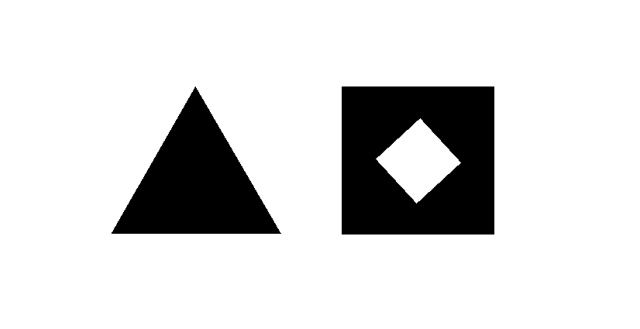

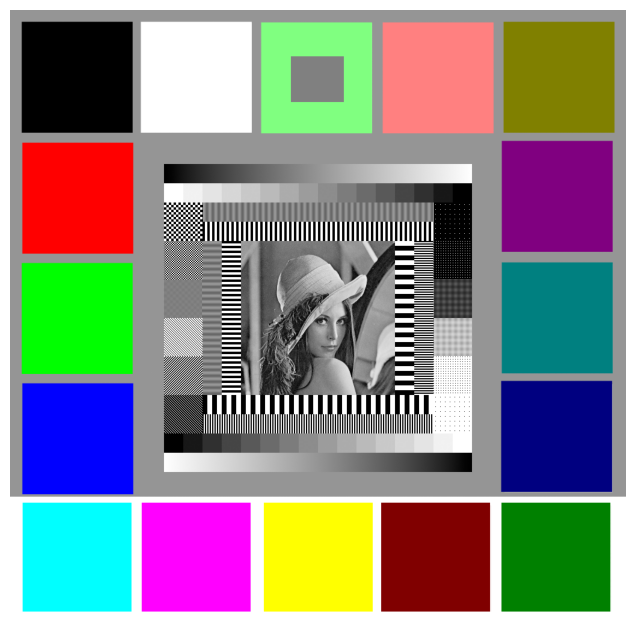

In [8]:
image_path = ["Imagens/shapes.png", "Imagens/testpat.tif"]

for image in image_path:
    show_image(image)

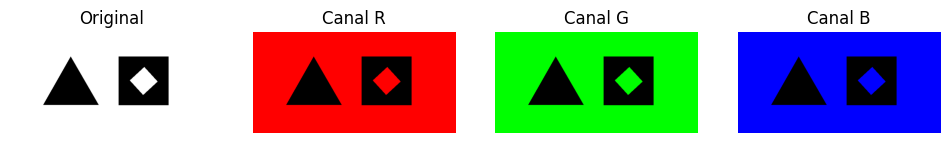

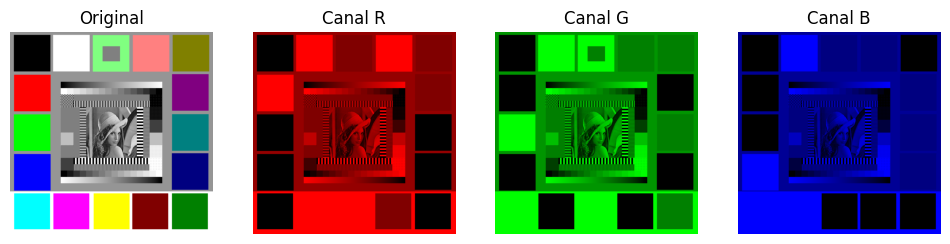

In [ ]:
for image in image_path:
    r, g, b, r_color, g_color, b_color, rgb = separar_canais_rgb(image)
    exibir_canais_rgb(r_color, g_color, b_color, rgb)

In [11]:
def ler_parametros(filepath: str):
    
    with open(filepath, 'r') as file:
        parametros = json.load(file)
    
    stride = parametros.get("stride")
    dilatacao = parametros.get("dilatacao")
    dimensoes = parametros.get("dimensoes")
    filtro = np.array(parametros.get("filtro"))
    ativacao = parametros.get("ativacao")
    
    return stride, dilatacao, dimensoes, filtro, ativacao

def validar_parametros(stride: int, dilatacao: int, dimensoes: list, filtro: np.array, ativacao: str):
    erros = []

    if not (1 <= dilatacao <= 5):
        erros.append(f"Dilatação inválida: {dilatacao}. Deve ser um inteiro entre 1 e 5.")

    if not (1 <= stride <= 5):
        erros.append(f"Stride inválido: {stride}. Deve ser um inteiro entre 1 e 5.")

    if len(dimensoes) != 2 or (dimensoes[0] <= 0 or dimensoes[1] <= 0):
        erros.append(f"Dimensões inválidas: {dimensoes}. Deve ser uma lista com dois inteiros positivos [m, n].")

    ativacoes_validas = ["relu", "identity"]
    if ativacao not in ativacoes_validas:
        erros.append(f"Ativação inválida: '{ativacao}'. Deve ser uma das: {ativacoes_validas}.")

    if erros:
        print("Erros encontrados nos parâmetros:")
        for erro in erros:
            print(f"  - {erro}")
        return False
    
    print("Parâmetros válidos!")
    return True

def mostrar_parametros(stride: int, dilatacao: int, dimensoes: list, filtro: np.array, ativacao: str):
    print("Parâmetros lidos:")
    print(f"Stride: {stride}")
    print(f"Dilatação: {dilatacao}")
    print(f"Dimensões do filtro: {dimensoes}")
    print(f"Filtro:\n{filtro}")
    print(f"Ativação: {ativacao}")

In [ ]:
path = "parametros/parametros.json"
stride, dilatacao, dimensoes, filtro, ativacao = ler_parametros(path)
mostrar_parametros(stride, dilatacao, dimensoes, filtro, ativacao)
validar_parametros(stride, dilatacao, dimensoes, filtro, ativacao)

Parâmetros lidos:
Stride: 2
Dilatação: 2
Dimensões do filtro: [3, 3]
Filtro:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]
Ativação: relu


In [14]:
def correlacao_atrous(nome_canal: str, canal: np.ndarray, filtro: np.ndarray, dilatacao: int, stride: int, ativacao: str) -> np.ndarray:
    """
    Aplica correlação atrous (dilatada) em um canal de imagem.
    """
    print(f"Iniciando correlação atrous com canal {nome_canal}")

    altura_img, largura_img = canal.shape
    altura_filtro, largura_filtro = filtro.shape
    print(f"Dimensão do canal: {canal.shape}, Dimensão do filtro: {filtro.shape}")
    
    altura_filtro_dilat = (altura_filtro - 1) * dilatacao + 1
    largura_filtro_dilat = (largura_filtro - 1) * dilatacao + 1
    print(f"Tamanho efetivo do filtro com dilatação: ({altura_filtro_dilat}, {largura_filtro_dilat})")
    
    altura_dilatada = (altura_img - altura_filtro_dilat) // stride + 1
    largura_dilatada = (largura_img - largura_filtro_dilat) // stride + 1
    saida = np.zeros((altura_dilatada, largura_dilatada), dtype=np.float32)
    print(f"Dimensão da saída: {saida.shape}")
    
    for i in range(0, altura_img - altura_filtro_dilat + 1, stride):
        for j in range(0, largura_img - largura_filtro_dilat + 1, stride):
            soma = 0.0
            
            for ki in range(altura_filtro):
                for kj in range(largura_filtro):
                    pos_i = i + ki * dilatacao
                    pos_j = j + kj * dilatacao
                    soma += canal[pos_i, pos_j] * filtro[ki, kj]
            
            out_i = i // stride
            out_j = j // stride
            saida[out_i, out_j] = soma
    
    if ativacao == "relu":
        print("Aplicando ReLU")
        saida = np.maximum(0, saida)
    
    return saida


def normalizar_filtro_se_necessario(filtro: np.ndarray) -> np.ndarray:
    filtro_float = filtro.astype(np.float32)
    soma_filtro = float(np.sum(filtro_float))

    if soma_filtro > 0 and not np.isclose(soma_filtro, 1.0):
        print(f"Normalizando filtro pela soma dos pesos: {soma_filtro}")
        return filtro_float / soma_filtro

    print(f"Filtro mantido sem normalização (soma={soma_filtro})")
    return filtro_float


def rgb_float_para_uint8(imagem_rgb_float: np.ndarray) -> np.ndarray:
    min_val = float(np.min(imagem_rgb_float))
    max_val = float(np.max(imagem_rgb_float))

    if min_val < 0.0 or max_val > 255.0:
        print(f"Reescalando imagem final para evitar saturação (min={min_val:.2f}, max={max_val:.2f})")
        if np.isclose(max_val, min_val):
            return np.zeros_like(imagem_rgb_float, dtype=np.uint8)

        imagem_norm = (imagem_rgb_float - min_val) / (max_val - min_val)
        return (imagem_norm * 255.0).astype(np.uint8)

    return np.clip(imagem_rgb_float, 0, 255).astype(np.uint8)


def processar_imagem_rgb(r: np.ndarray, g: np.ndarray, b: np.ndarray,
                        stride: int, dilatacao: int, filtro: np.ndarray, ativacao: str):

    filtro_proc = normalizar_filtro_se_necessario(filtro)

    r_out = correlacao_atrous("R", r, filtro_proc, dilatacao, stride, ativacao)
    g_out = correlacao_atrous("G", g, filtro_proc, dilatacao, stride, ativacao)
    b_out = correlacao_atrous("B", b, filtro_proc, dilatacao, stride, ativacao)
    print("Canais processados, saindo tipo: ", r_out.dtype)

    imagem_float = np.stack([r_out, g_out, b_out], axis=2).astype(np.float32)
    imagem_processada = rgb_float_para_uint8(imagem_float)

    r_u8 = imagem_processada[:, :, 0]
    g_u8 = imagem_processada[:, :, 1]
    b_u8 = imagem_processada[:, :, 2]

    r_color = np.stack([r_u8, np.zeros_like(r_u8), np.zeros_like(r_u8)], axis=2)
    g_color = np.stack([np.zeros_like(g_u8), g_u8, np.zeros_like(g_u8)], axis=2)
    b_color = np.stack([np.zeros_like(b_u8), np.zeros_like(b_u8), b_u8], axis=2)
    print("Canais coloridos criados, saindo tipo: ", r_color.dtype)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(r_color)
    axs[0].set_title("Canal R processado")
    axs[0].axis("off")

    axs[1].imshow(g_color)
    axs[1].set_title("Canal G processado")
    axs[1].axis("off")

    axs[2].imshow(b_color)
    axs[2].set_title("Canal B processado")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

    print("Imagem processada final, tipo: ", imagem_processada.dtype)
    print("Range final [min, max]:", int(imagem_processada.min()), int(imagem_processada.max()))

    return imagem_processada

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [5, 5]
Filtro:
[[ 1  4  6  4  1]
 [ 4 16 24 16  4]
 [ 6 24 36 24  6]
 [ 4 16 24 16  4]
 [ 1  4  6  4  1]]
Ativação: relu
Normalizando filtro pela soma dos pesos: 256.0
Iniciando correlação atrous com canal R
Dimensão do canal: (1024, 1024), Dimensão do filtro: (5, 5)
Tamanho efetivo do filtro com dilatação: (5, 5)
Dimensão da saída: (1020, 1020)
Aplicando ReLU
Iniciando correlação atrous com canal G
Dimensão do canal: (1024, 1024), Dimensão do filtro: (5, 5)
Tamanho efetivo do filtro com dilatação: (5, 5)
Dimensão da saída: (1020, 1020)
Aplicando ReLU
Iniciando correlação atrous com canal B
Dimensão do canal: (1024, 1024), Dimensão do filtro: (5, 5)
Tamanho efetivo do filtro com dilatação: (5, 5)
Dimensão da saída: (1020, 1020)
Aplicando ReLU
Canais processados, saindo tipo:  float32
Canais coloridos criados, saindo tipo:  uint8


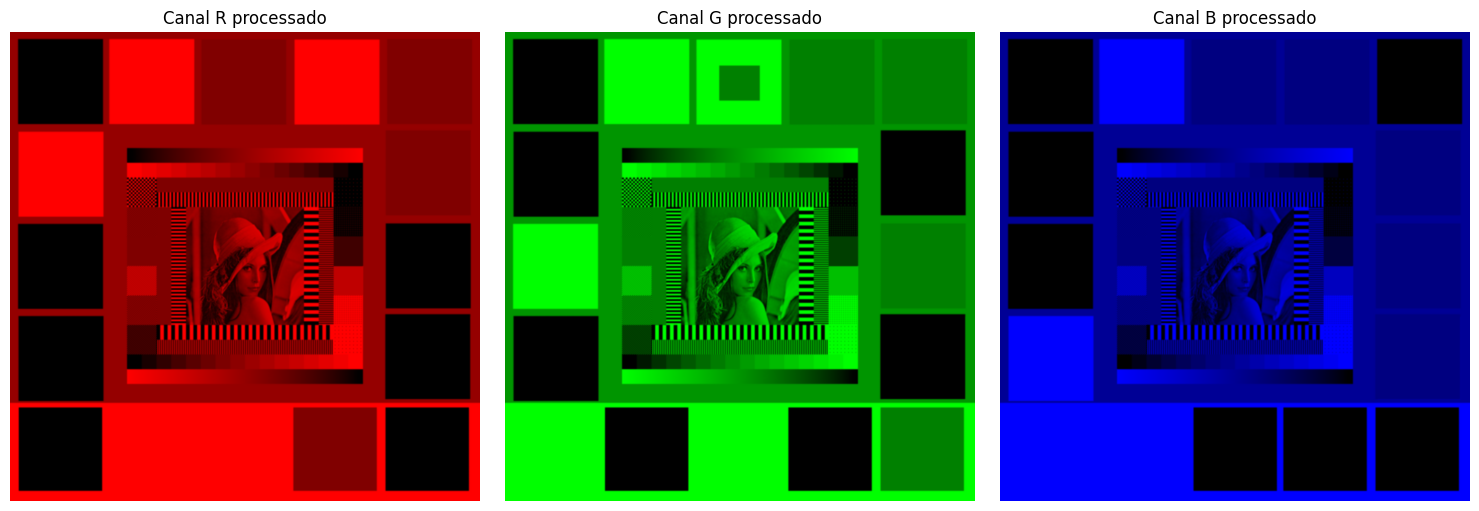

Imagem processada final, tipo:  uint8
Range final [min, max]: 0 255


In [15]:
#função manual
stride, dilatacao, dims, filtro_gauss5_5, ativacao = ler_parametros("parametros/gaussiano5_5.json")

mostrar_parametros(stride, dilatacao, dims, filtro_gauss5_5, ativacao)
gaussiano_manual = processar_imagem_rgb(r, g, b, 
                                stride, dilatacao, filtro_gauss5_5, ativacao)

In [16]:
os.makedirs("resultados", exist_ok=True)
salvar_imagem("resultados/gaussiano_manual.jpg", gaussiano_manual)

Imagem salva em: resultados/gaussiano_manual.jpg


In [17]:
# função pronta (sem padding: "valid")
img_cv = cv2.imread(image_path[1])
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

ksize = (5, 5)
gaussiano_opencv = cv2.GaussianBlur(img_cv, ksize, sigmaX=1.0)

pad_h = ksize[0] // 2
pad_w = ksize[1] // 2
gaussiano_opencv_nop = gaussiano_opencv[pad_h:-pad_h, pad_w:-pad_w]
print("Dimensão do resultado OpenCV com padding:", gaussiano_opencv.shape)
print("Dimensão do resultado OpenCV sem padding:", gaussiano_opencv_nop.shape)

Dimensão do resultado OpenCV com padding: (1024, 1024, 3)
Dimensão do resultado OpenCV sem padding: (1020, 1020, 3)


In [18]:
os.makedirs("resultados", exist_ok=True)
cv2.imwrite("resultados/opencv_gaussiano.jpg", cv2.cvtColor(gaussiano_opencv, cv2.COLOR_RGB2BGR))
cv2.imwrite("resultados/opencv_gaussiano_nop.jpg", cv2.cvtColor(gaussiano_opencv_nop, cv2.COLOR_RGB2BGR))

True

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [5, 5]
Filtro:
[[ 1  4  6  4  1]
 [ 4 16 24 16  4]
 [ 6 24 36 24  6]
 [ 4 16 24 16  4]
 [ 1  4  6  4  1]]
Ativação: relu


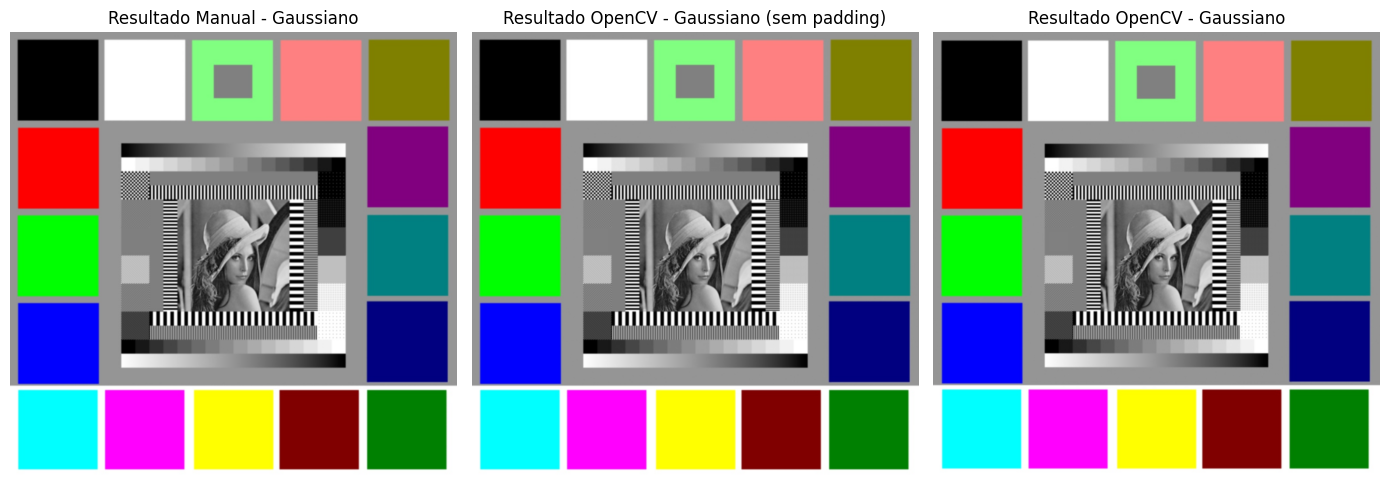

In [19]:
mostrar_parametros(stride, dilatacao, dims, filtro_gauss5_5, ativacao)
img_manual = np.array(Image.open("resultados/manual_gaussiano.jpg"))
img_opencv_nop = np.array(Image.open("resultados/opencv_gaussiano_nop.jpg"))
img_opencv = np.array(Image.open("resultados/opencv_gaussiano.jpg"))

plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_manual)
plt.title("Resultado Manual - Gaussiano")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_opencv_nop)
plt.title("Resultado OpenCV - Gaussiano (sem padding)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_opencv)
plt.title("Resultado OpenCV - Gaussiano")
plt.axis("off")

plt.tight_layout()
plt.show()

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [1, 10]
Filtro:
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
Ativação: identity
Normalizando filtro pela soma dos pesos: 10.0
Iniciando correlação atrous com canal R
Dimensão do canal: (1024, 1024), Dimensão do filtro: (1, 10)
Tamanho efetivo do filtro com dilatação: (1, 10)
Dimensão da saída: (1024, 1015)
Iniciando correlação atrous com canal G
Dimensão do canal: (1024, 1024), Dimensão do filtro: (1, 10)
Tamanho efetivo do filtro com dilatação: (1, 10)
Dimensão da saída: (1024, 1015)
Iniciando correlação atrous com canal B
Dimensão do canal: (1024, 1024), Dimensão do filtro: (1, 10)
Tamanho efetivo do filtro com dilatação: (1, 10)
Dimensão da saída: (1024, 1015)
Canais processados, saindo tipo:  float32
Canais coloridos criados, saindo tipo:  uint8


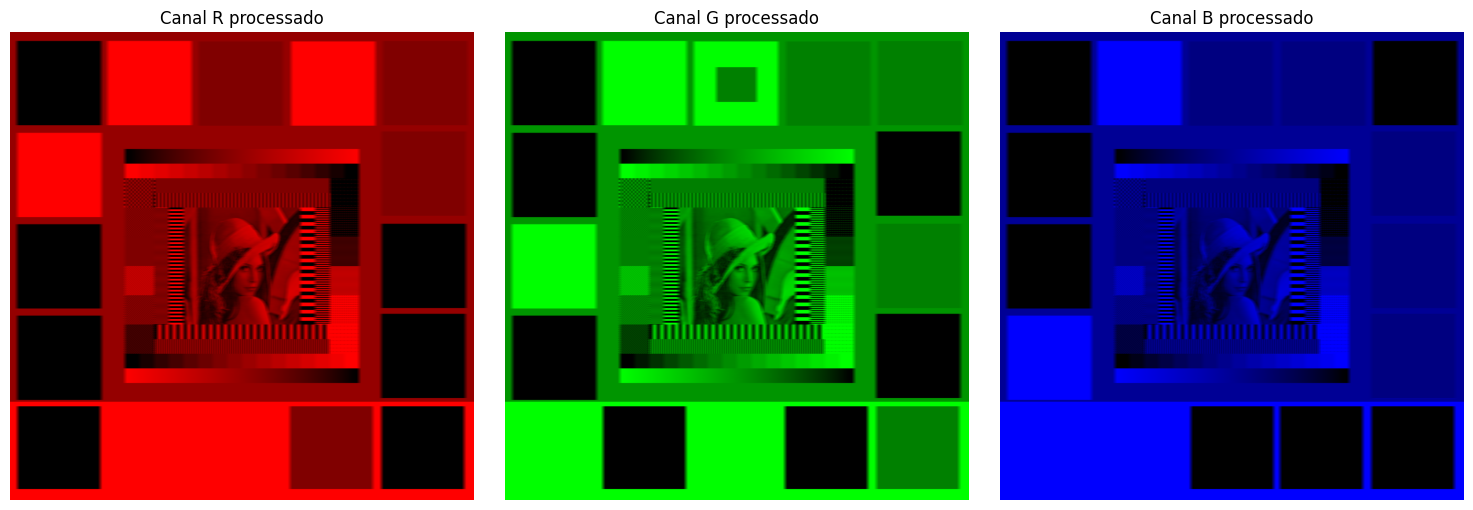

Imagem processada final, tipo:  uint8
Range final [min, max]: 0 255
Shape manual: (1024, 1015, 3)
Shape OpenCV valid: (1024, 1015, 3)
MAE: 2.2972919232348112
Diferença máxima: 26


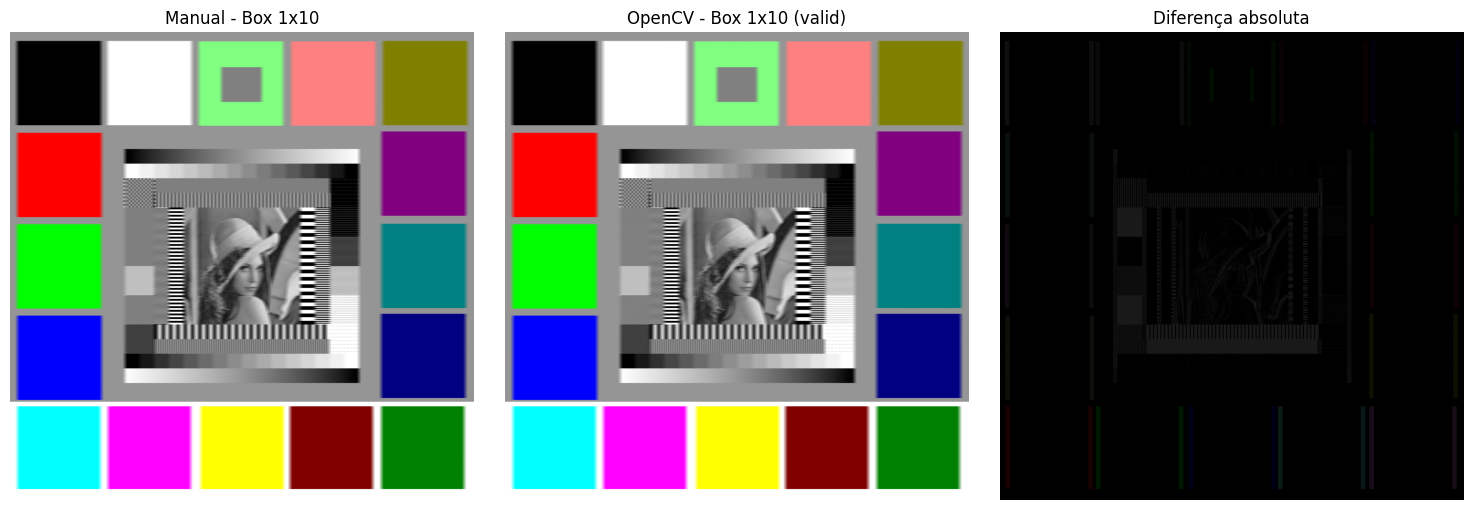

True

In [20]:
# Teste com filtro BOX 1x10 (manual x OpenCV)

filtro_box_1x10 = np.ones((1, 10), dtype=np.float32)
stride_box = 1
dilatacao_box = 1
ativacao_box = "identity"

mostrar_parametros(
    stride_box,
    dilatacao_box,
    list(filtro_box_1x10.shape),
    filtro_box_1x10,
    ativacao_box
)

# Manual (correlação atrous já implementada)
box_manual = processar_imagem_rgb(
    r, g, b,
    stride_box, dilatacao_box,
    filtro_box_1x10, ativacao_box
)

# OpenCV (box blur) e recorte "valid" equivalente ao manual
# ksize no OpenCV = (largura, altura)
box_opencv = cv2.blur(img_cv, ksize=(10, 1))
box_opencv_valid = box_opencv[:, 4:-5, :]  # equivale ao "valid" para kernel 1x10

print("Shape manual:", box_manual.shape)
print("Shape OpenCV valid:", box_opencv_valid.shape)

# Métricas de diferença
diff_box = np.abs(box_manual.astype(np.int16) - box_opencv_valid.astype(np.int16))
print("MAE:", float(np.mean(diff_box)))
print("Diferença máxima:", int(np.max(diff_box)))

# Visualização
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(box_manual)
plt.title("Manual - Box 1x10")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(box_opencv_valid)
plt.title("OpenCV - Box 1x10 (valid)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(diff_box)
plt.title("Diferença absoluta")
plt.axis("off")

plt.tight_layout()
plt.show()

# Salvar resultados
os.makedirs("resultados", exist_ok=True)
cv2.imwrite("resultados/manual_box_1x10.jpg", cv2.cvtColor(box_manual, cv2.COLOR_RGB2BGR))
cv2.imwrite("resultados/opencv_box_1x10_valid.jpg", cv2.cvtColor(box_opencv_valid, cv2.COLOR_RGB2BGR))